<h1>Problem Set 2</h1>
This problem set will focus on setting up and solving integer linear programming problems. Before starting this problem, we assume that you have already studied the tutorial on setting up integer linear programming problems in pulp.

<h2>Problem 1</h2>
In this problem, you will setup and solve the three coloring problem as a integer linear programming problem.

The three coloring problem inputs an undirected graph  𝐺   with vertices  𝑉={1,…,𝑛}   and undirected edges  𝐸. We are looking to color each vertex one of three colors red, green or blue such that for any edge  (𝑖,𝑗)   the nodes  𝑖,𝑗  have different colors.

Given a graph, we wish to know if a three coloring is possible and if so, we wish to find the three coloring. Although this problem seems like a toy problem, it has applications to many practical problems in resource allocation and other areas.

First, we ask you to setup the three coloring problem as an integer linear program.

<h3>My thought</h3>
Decision variables - 3 binary integer decision variables  per vertex - xi1 xi2 xi3 (xi1 => color 1 is assigned to vertex i, xi2 => color 2 is assigned to vertex i, xi3 => color 3 is assigned to vertex i)

Objective - Maximize(xi1+xi2+xi3) for i = 1 to n => it will try to assign color/colors to all vertices. We put constraints so that one vertex can get only one color. 

Constraints - 
<ul><li>
xi1+xi2+xi3 <= 1 {only one color can be assigned to a decision variable}
</li><li>
xu1+xv1 <= 0 where (u,v) belong to edge E - makes sure both vertices of an edge are not both of color1
</li><li>
xu2+xv2 <= 0 where (u,v) belong to edge E - makes sure both vertices of an edge are not both of color2
</li><li>
xu3+xv3 <= 0 where (u,v) belong to edge E - makes sure both vertices of an edge are not both of color3
</li></ul>
<h3>course thought- the same !!!</h3>



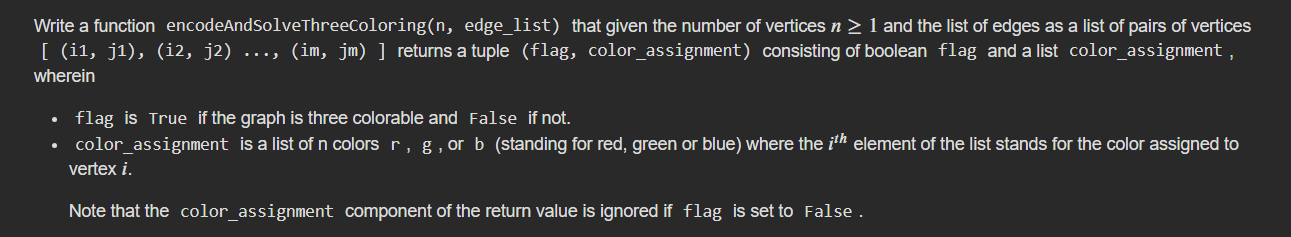

In [24]:
from pulp import *

def encode_and_solve_three_coloring(n, edge_list):
    assert n >= 1, 'Graph must have at least one vertex'
    assert all( 0 <= i and i < n and 0 <= j and j < n and i != j for (i,j) in edge_list ), 'Edge list is not well formed'
    prob = LpProblem('Three Color', LpMaximize)
    #1. Formulate the decision variables
    dvars = [LpVariable(f'x{i}_{j}',cat='Binary')   for i in range(n) for j in range(3)]
    prob += sum(dvars)
    #2. Add the constraints for each vertex and edge in the graph.
    for i in range(n):  # each vertex can have only one color
        prob +=  dvars[3*i]+dvars[3*i+1]+dvars[3*i+2] <= 1
        prob +=  dvars[3*i]+dvars[3*i+1]+dvars[3*i+2] >= 1 # each vertex should have one color assigned
    for (u,v) in edge_list:
        prob +=  dvars[3*u]+dvars[3*v]<=1
        prob +=  dvars[3*u+1]+dvars[3*v+1]<=1
        prob +=  dvars[3*u+2]+dvars[3*v+2]<=1

    #3. Solve and interpret the status of the solution.
    status = prob.solve()
    flag = True
    if status == constants.LpStatusInfeasible:
        print('infeasible')
        flag = False
    elif status == constants.LpStatusUnbounded:
        print('unbounded')
        flag = False
    else: # optimal?
        assert status == LpStatusOptimal, 'Problem results in undefined status -- cannot continue'
        print('optimal')

    def getColor(i, dvarValue):
        if dvarValue==1 and i%3==0:
            return 'g'
        elif dvarValue==1 and i%3==1:
            return 'r'
        elif dvarValue==1 and i%3==2:
            return 'b'
        else:
            return ''

    #4. Return the result in the required form to pass the tests below.
    solution_values = [getColor(i,x.varValue) for (i, x) in enumerate(dvars)]
    # print(f'solution_values={solution_values}')
    colors_assigned = [x for x in solution_values if x]
    return (flag, colors_assigned)
    

In [25]:
n = 5
edge_list = [(1,2), (1, 3), (1,4), (2, 4), (3,4)]
(flag, color_assign) = encode_and_solve_three_coloring(n, edge_list)
assert flag == True, 'Error: Graph is three colorable but your code wrongly returns flag = False'
print(f'Three color assignment: {color_assign}')
def check_three_color_assign(n, edge_list, color_assign):
    assert len(color_assign) == n, f'Error: The list of color assignments has {len(color_assign)} entries but must be same as number of vertices {n}'
    assert all( col == 'r' or col == 'b' or col == 'g' for col in color_assign), f'Error: Each entry in color assignment list must be r, g or b. Your code returned: {color_assign}'
    for (i, j) in edge_list:
        ci = color_assign[i]
        cj = color_assign[j]
        assert ci != cj, f' Error: For edge ({i,j}) we have same color assignment ({ci, cj})'
    print('Success: Three coloring assignment checks out!!')
        
check_three_color_assign(n, edge_list, color_assign)
print('Passed: 10 points!')

optimal
Three color assignment: ['b', 'r', 'g', 'g', 'b']
Success: Three coloring assignment checks out!!
Passed: 10 points!


In [26]:
n = 5
edge_list = [(1,2), (1, 3), (1,4), (2,3), (2, 4), (3,4)]
(flag, color_assign) = encode_and_solve_three_coloring(n, edge_list)
assert flag == False, 'Error: Graph is NOT three colorable but your code wrongly returns flag = True'
print('Passed: 5 points!')

infeasible
Passed: 5 points!


In [27]:
n = 10
edge_list = [ (1, 5), (1, 7), (1, 9), (2, 4), (2, 5), (2, 9), (3, 4), (3, 6), (3,7), (3,8), (4, 5), (4,6), (4,7), (4,9),(5,6), (5,7),(6,8),(7,9),(8,9)]
(flag, color_assign) = encode_and_solve_three_coloring(n, edge_list)
assert flag == True, 'Error: Graph is three colorable but your code wrongly returns flag = False'
print(f'Three color assignment: {color_assign}')
def check_three_color_assign(n, edge_list, color_assign):
    assert len(color_assign) == n, f'Error: The list of color assignments has {len(color_assign)} entries but must be same as number of vertices {n}'
    assert all( col == 'r' or col == 'b' or col == 'g' for col in color_assign), f'Error: Each entry in color assignment list must be r, g or b. Your code returned: {color_assign}'
    for (i, j) in edge_list:
        ci = color_assign[i]
        cj = color_assign[j]
        assert ci != cj, f' Error: For edge ({i,j}) we have same color assignment ({ci, cj})'
    print('Success: Three coloring assignment checks out!!')
        
check_three_color_assign(n, edge_list, color_assign)
print('Passed: 5 points!')

optimal
Three color assignment: ['b', 'b', 'r', 'g', 'b', 'g', 'r', 'r', 'b', 'g']
Success: Three coloring assignment checks out!!
Passed: 5 points!


<h2>Problem2</h2>

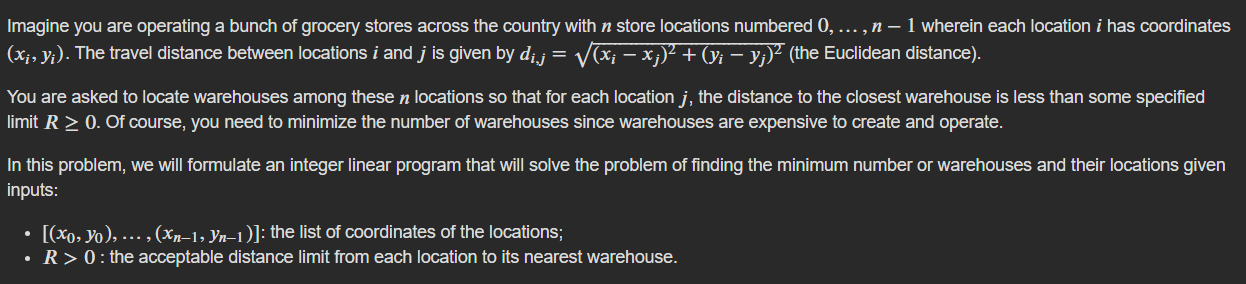

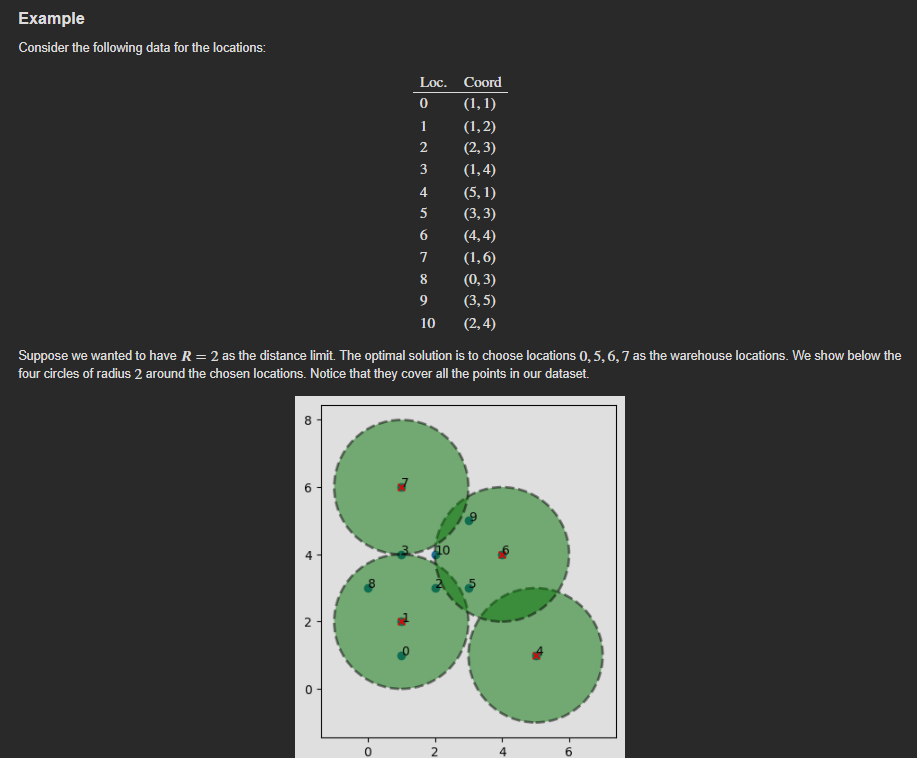

Lets formulate ILP -

<h3>My thought</h3>
<ul>
<li>This is atleast O(n<sup>2</sup>) algorithm distance between all vertexes need to be calculated to get value of d(i,j) which is 1 then distance between vertices i and j is <= radius limit. </li><li>Decision variables (di) for each vertex which is 0 if this vertex is not included in resultset, 1 if this vertes is included in resultset.</li><li>Objective is to minimize the sum of decision variables (i.e., select minimum number of locations to include in resultset).</li><li>Constraint - for each vertex i - (di + for all vertexes y!=i dist(i,y)*dy)>=1 .., this esures that- either current vertrex is included in resultset (i.e., one of selected warehouses) or for all other vertices that are selected as warehouse location atleast one of them is at distance of given radius. Note d(i,y) =1 is the distance between i-y is <= given radius limit</li>
</ul>

<h3>solution given - same as what I thought!!!</h3>

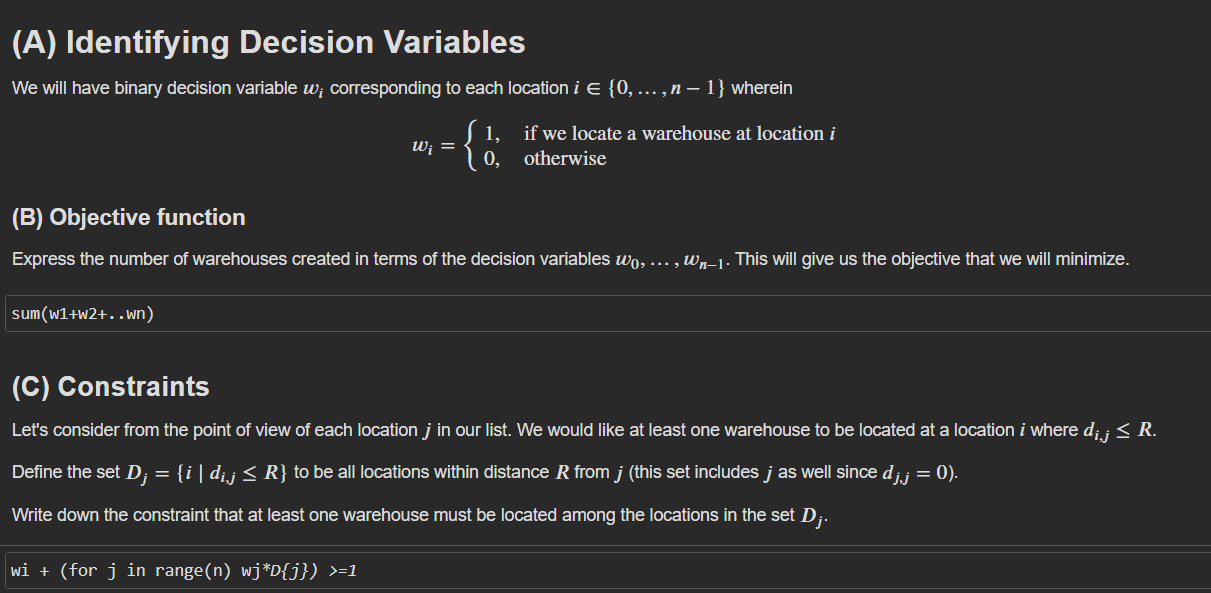



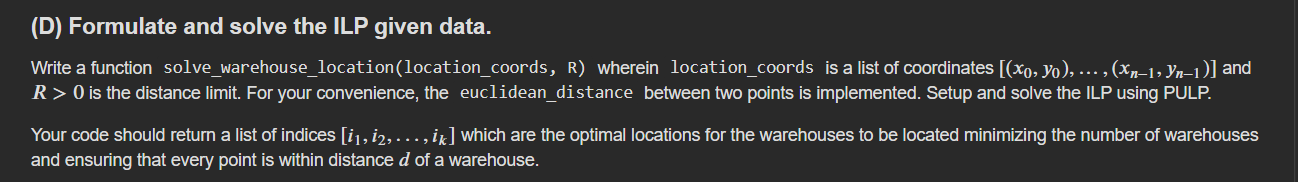

In [47]:
from pulp import *
from math import sqrt 


def euclidean_distance(location_coords, i, j):
    assert 0 <= i and i < len(location_coords)
    assert 0 <= j and j < len(location_coords)
    if i == j: 
        return 0.0
    (xi, yi) = location_coords[i] # unpack coordinate
    (xj, yj) = location_coords[j]
    return sqrt( (xj - xi)**2 + (yj - yi)**2 )


def solve_warehouse_location(location_coords, R):
    assert R > 0.0, 'radius must be positive'
    n = len(location_coords)
    distances = {i:{} for i in range(n)}
    for i in range(n):
        for j in range(n):
            if(i==j):
                continue
            dist = euclidean_distance(location_coords, i, j)
            if dist <= R:
                distances[i][j]=1
            else:
                distances[i][j]=0

    print(f'distances{distances}')
    prob = LpProblem('Warehouselocation', LpMinimize)
    #1. Formulate the decision variables
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(n)]
    #2. Add the constraints for each vertex and edge in the graph.
    prob += lpSum(dvars)
    for i in range(n):
        tmp = [dvars[j]*distances[i][j] for j in range(n) if j!=i]
        tmp.append(dvars[i])        
        prob +=  lpSum(tmp) >= 1
    #3. Solve and interpret the status of the solution.
    status = prob.solve()
    #4. Return the result in the required form to pass the tests below.
    if status == constants.LpStatusInfeasible:
        print('infeasible')
    elif status == constants.LpStatusUnbounded:
        print('unbounded')
    else: # optimal?
        assert status == LpStatusOptimal, 'Problem results in undefined status -- cannot continue'
        print('optimal')
    # your code here
    return [i for (i,var) in enumerate(dvars) if var.varValue==1]


distances{0: {1: 1, 2: 0, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0}, 1: {0: 1, 2: 1, 3: 1, 4: 1, 5: 0, 6: 0, 7: 0}, 2: {0: 0, 1: 1, 3: 0, 4: 1, 5: 1, 6: 0, 7: 0}, 3: {0: 1, 1: 1, 2: 0, 4: 0, 5: 0, 6: 0, 7: 0}, 4: {0: 0, 1: 1, 2: 1, 3: 0, 5: 1, 6: 0, 7: 0}, 5: {0: 0, 1: 0, 2: 1, 3: 0, 4: 1, 6: 0, 7: 0}, 6: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 7: 0}, 7: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}}
optimal
Your code returned warehouse locatitons: [0, 5, 6, 7]
Your solution passed test


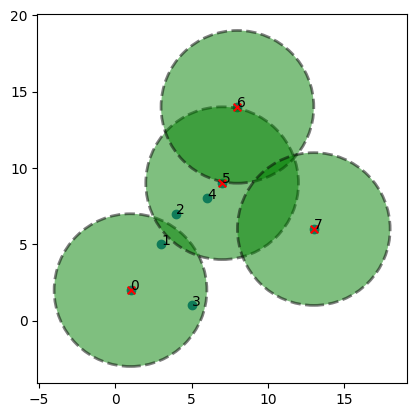

In [48]:
from matplotlib import pyplot as plt 

def check_solution(location_coords, R, warehouse_locs):
    # for each location i, calculate all locations j within distance R of location i
    # use list comprehension instead of accumulating using a nested for loop.
    n = len(location_coords)
    assert all(j >= 0 and j < n for j in warehouse_locs), f'Warehouse locations must be between 0 and {n-1}'
    neighborhoods = [ [j for j in range(n) if euclidean_distance(location_coords, i, j) <= R] for i in range(n)]
    W = set(warehouse_locs)
    for (i, n_list)  in enumerate(neighborhoods):
        assert any(j in W for j in n_list), f'Location # {i} has no warehouse within distance {R}. The locations within distance {R} are {n_list}'
    print('Your solution passed test')
    
def visualize_solution(location_coords, R, warehouse_locs):
    n = len(location_coords)
    (xCoords, yCoords) = zip(*location_coords)
    warehouse_x, warehouse_y = [xCoords[j] for j in warehouse_locs], [yCoords[j] for j in warehouse_locs]
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    plt.scatter(xCoords, yCoords)
    for j in warehouse_locs: 
        circ = plt.Circle(location_coords[j], R, alpha=0.5, color='g',ls='--',lw=2,ec='k')
        ax.add_patch(circ)
    
    for i in range(n):
        (x,y) = location_coords[i]
        ax.annotate(f'{i}', location_coords[i])
    
    plt.scatter(warehouse_x, warehouse_y, marker='x',c='r', s=30)
        
    
    
    
location_coords = [(1,2), (3, 5), (4, 7), (5, 1), (6, 8), (7, 9), (8,14), (13,6)]
R = 5
locs = solve_warehouse_location(location_coords, R )
print(f'Your code returned warehouse locatitons: {locs}')
assert len(locs) <= 4, f'Error: There is an solution involving just 4 locations whereas your code returns {len(locs)}'
visualize_solution(location_coords, R, locs)


check_solution(location_coords, R, locs)

R = 2 Test:
distances{0: {1: 1, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}, 1: {0: 1, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0, 8: 1, 9: 0, 10: 0}, 2: {0: 0, 1: 1, 3: 1, 4: 0, 5: 1, 6: 0, 7: 0, 8: 1, 9: 0, 10: 1}, 3: {0: 0, 1: 1, 2: 1, 4: 0, 5: 0, 6: 0, 7: 1, 8: 1, 9: 0, 10: 1}, 4: {0: 0, 1: 0, 2: 0, 3: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}, 5: {0: 0, 1: 0, 2: 1, 3: 0, 4: 0, 6: 1, 7: 0, 8: 0, 9: 1, 10: 1}, 6: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 7: 0, 8: 0, 9: 1, 10: 1}, 7: {0: 0, 1: 0, 2: 0, 3: 1, 4: 0, 5: 0, 6: 0, 8: 0, 9: 0, 10: 0}, 8: {0: 0, 1: 1, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0, 9: 0, 10: 0}, 9: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 6: 1, 7: 0, 8: 0, 10: 1}, 10: {0: 0, 1: 0, 2: 1, 3: 1, 4: 0, 5: 1, 6: 1, 7: 0, 8: 0, 9: 1}}
optimal
Your code returned warehouse locatitons: [1, 4, 6, 7]
Your solution passed test
Test with R= 2 has passed
R=3 Test:
distances{0: {1: 1, 2: 1, 3: 1, 4: 0, 5: 1, 6: 0, 7: 0, 8: 1, 9: 0, 10: 0}, 1: {0: 1, 2: 1, 3: 1, 4: 0, 5: 1, 6: 0, 7: 0, 8: 1, 

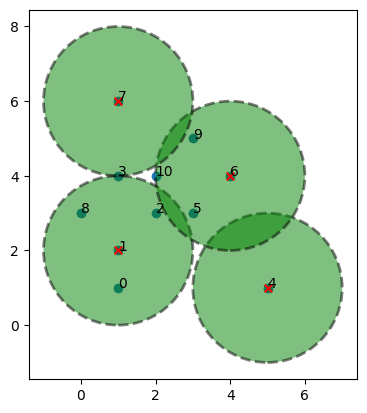

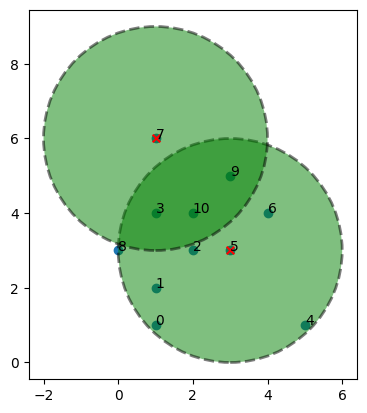

In [49]:
from matplotlib import pyplot as plt 

def check_solution(location_coords, R, warehouse_locs):
    # for each location i, calculate all locations j within distance R of location i
    # use list comprehension instead of accumulating using a nested for loop.
    n = len(location_coords)
    assert all(j >= 0 and j < n for j in warehouse_locs), f'Warehouse locations must be between 0 and {n-1}'
    neighborhoods = [ [j for j in range(n) if euclidean_distance(location_coords, i, j) <= R] for i in range(n)]
    W = set(warehouse_locs)
    for (i, n_list)  in enumerate(neighborhoods):
        assert any(j in W for j in n_list), f'Location # {i} has no warehouse within distance {R}. The locations within distance {R} are {n_list}'
    print('Your solution passed test')
    
def visualize_solution(location_coords, R, warehouse_locs):
    n = len(location_coords)
    (xCoords, yCoords) = zip(*location_coords)
    warehouse_x, warehouse_y = [xCoords[j] for j in warehouse_locs], [yCoords[j] for j in warehouse_locs]
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    plt.scatter(xCoords, yCoords)
    for j in warehouse_locs: 
        circ = plt.Circle(location_coords[j], R, alpha=0.5, color='g',ls='--',lw=2,ec='k')
        ax.add_patch(circ)
    
    for i in range(n):
        (x,y) = location_coords[i]
        ax.annotate(f'{i}', location_coords[i])
    
    plt.scatter(warehouse_x, warehouse_y, marker='x',c='r', s=30)
        
    
    
    
location_coords = [(1,1), (1, 2), (2, 3), (1, 4), (5, 1), (3, 3), (4,4), (1,6), (0,3), (3,5), (2,4)]

## TEST 1
R = 2
print("R = 2 Test:")
locs = solve_warehouse_location(location_coords, R )
print(f'Your code returned warehouse locatitons: {locs}')
assert len(locs) <= 4, f'Error: There is an solution involving just 4 locations whereas your code returns {len(locs)}'
visualize_solution(location_coords, R, locs)
check_solution(location_coords, R, locs)
print('Test with R= 2 has passed')
## TEST 2
print("R=3 Test:")
R = 3
locs3 = solve_warehouse_location(location_coords, R )
print(f'Your code returned warehouse locatitons: {locs3}')
assert len(locs3) <= 2, f'Error: There is an solution involving just 4 locations whereas your code returns {len(locs)}'
visualize_solution(location_coords, R, locs3)
check_solution(location_coords, R, locs3)
print("Test with R = 3 has passed.")
